# **PPG dataset exploration (BUT PPG)**
In this notebook we *only visualize* the **PPG** modality of our project, the [**Brno University of Technology Smartphone PPG Database (BUT PPG)**](https://physionet.org/content/butppg/).

Each record is stored in **PhysioNet WFDB** format (`.hea` header + `.dat` samples). For every recording the package provides a **PPG** signal, an **ECG** signal and a `subject-info.csv` with demographics (**Age**, **Gender**, ...), which is exactly what we need for the age-regression task.

# **Preliminary operations**
The lab notebooks fetch their data on the fly (e.g. `!wget ...` in *DL_01: Regression*).
This project instead uses **non-public, provisional archives** that we keep **locally** and
**out of version control** (`*.zip` and `proj_files/` are git-ignored). There is therefore
nothing to download here.

Before running the notebook, place the dataset archives under `proj_files/` at the
repository root:

```
proj_files/
├── MMCBNU_6000.zip                                            ← FingerVein
└── brno-university-of-technology-...-but-ppg-2.0.0.zip        ← PPG
```

We read the data **directly from the `.zip`** (extracting each WFDB record to a temporary folder, since `wfdb` reads from files), so the archives do not need to be
extracted.


# **Useful module imports**
As in the labs, we import every module first, then fix a documented random seed.

`wfdb` reads records from files, so we extract each record to a temporary folder on the fly
(`tempfile`/`os`). Signals are processed with `numpy`/`scipy` (band-pass filtering) and
plotted with `matplotlib`.


In [1]:
import io
import os
import zipfile
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import wfdb

# Reproducibility: one documented seed (see AGENTS.md, "Scientific constraints").
SEED = 0
np.random.seed(SEED)

# **Datasets**
This notebook explores the **PPG** modality: the **Brno University of Technology Smartphone
PPG Database (BUT PPG)**, distributed on PhysioNet.

| Property | Value |
|---|---|
| Unit of observation | one ~10 s PPG recording |
| Format | PhysioNet **WFDB** (`.hea` header + `.dat` samples) |
| Sampling rate | 30 Hz (smartphone-camera PPG) → ~300 samples per record |
| Labels | `subject-info.csv` → **Age [years]** (target) + **Gender** |

Each record also ships an ECG signal and beat annotations, which we ignore here. Unlike
FingerVein, the PPG age/gender come from a proper **CSV**, so the regression target is
directly available. This is still a **provisional public** dataset, not the non-public data
named in the proposal: results are exploratory.

The cell below locates the archive under `proj_files/` and reads it in place.


In [3]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'proj_files'
PPG_ZIP = DATA_DIR / 'brno-university-of-technology-smartphone-ppg-database-but-ppg-2.0.0.zip'

assert PPG_ZIP.exists(), f'PPG archive not found: {PPG_ZIP} (see "Preliminary operations")'
print('Repository root :', PROJECT_ROOT)
print('PPG zip         :', PPG_ZIP.name, f'({PPG_ZIP.stat().st_size / 1e6:.0f} MB)')

Repository root : /Users/muni/Documents/uni/DL/PPG_FingerVein_age_detection
PPG zip         : brno-university-of-technology-smartphone-ppg-database-but-ppg-2.0.0.zip (91 MB)


# **Subject information**
We load `subject-info.csv` straight from the archive. These are the **labels** for the project: the column *Age [years]* is our regression target.

In [4]:
with zipfile.ZipFile(PPG_ZIP) as z:
    csv_name = next(n for n in z.namelist() if n.endswith('subject-info.csv'))
    info = pd.read_csv(io.BytesIO(z.read(csv_name)))

print('records:', len(info))
info.head()

records: 3888


,ID,Gender,Age [years],Height [cm],Weight [kg],Ear/finger,Motion,Blood pressure [mmHg],Glycaemia [mmol/l],SpO2 [%]
0,100001,F,51,NaN,58,1,0,NaN,NaN,NaN
1,100002,F,51,NaN,58,1,0,NaN,NaN,NaN
2,100003,F,51,NaN,58,1,0,NaN,NaN,NaN
3,100004,F,51,NaN,58,1,2;3,NaN,NaN,NaN
4,101001,F,54,NaN,63,1,0,NaN,NaN,NaN


# **Age and gender distribution**
Inspecting the target distribution is important: a skewed age range will bias the model (see the error-analysis discussion in the proposal).

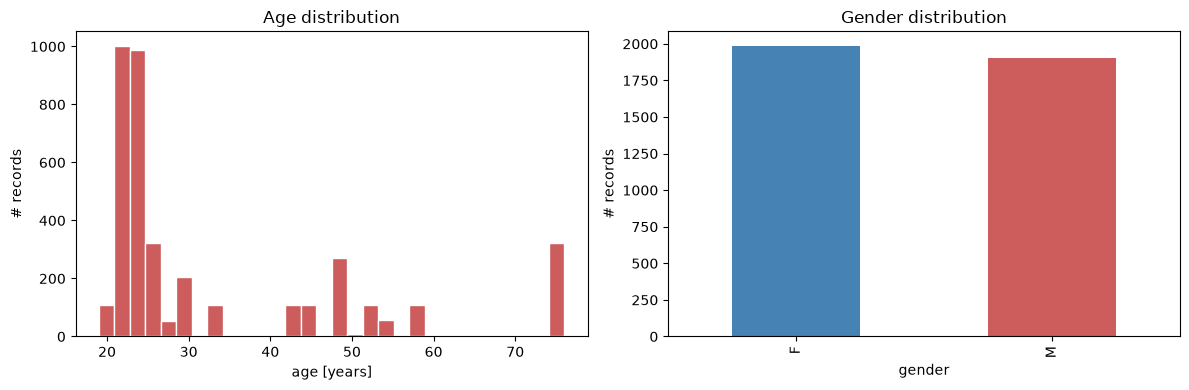

count    3888.0
mean       33.1
std        16.7
min        19.0
25%        22.0
50%        23.0
75%        44.0
max        76.0
Name: Age [years], dtype: float64


In [5]:
age = pd.to_numeric(info['Age [years]'], errors='coerce').dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(age, bins=30, color='indianred', edgecolor='white')
ax1.set_title('Age distribution')
ax1.set_xlabel('age [years]')
ax1.set_ylabel('# records')

info['Gender'].value_counts().plot.bar(ax=ax2, color=['steelblue', 'indianred'])
ax2.set_title('Gender distribution')
ax2.set_xlabel('gender')
ax2.set_ylabel('# records')
plt.tight_layout()
plt.show()

print(age.describe().round(1))

# **Utility functions**
- **list_records** returns the record IDs that have a PPG signal;
- **read_ppg** extracts one WFDB record from the archive and returns `(signal, fs)`.

In BUT PPG each 10-second PPG segment is stored as 300 single-sample *channels* at 30 Hz, so we flatten the WFDB matrix into a 1-D waveform.

In [6]:
def list_records(zip_path):
    with zipfile.ZipFile(zip_path) as z:
        heas = [n for n in z.namelist() if n.endswith('_PPG.hea')]
    return sorted(Path(h).stem.replace('_PPG', '') for h in heas)


def read_ppg(zip_path, record_id):
    base_in_zip = None
    with zipfile.ZipFile(zip_path) as z:
        for n in z.namelist():
            if n.endswith(f'{record_id}/{record_id}_PPG.hea'):
                base_in_zip = n[:-4]  # strip '.hea'
                break
        if base_in_zip is None:
            raise FileNotFoundError(record_id)
        with tempfile.TemporaryDirectory() as td:
            stem = os.path.basename(base_in_zip)
            for ext in ('.hea', '.dat'):
                with open(os.path.join(td, stem + ext), 'wb') as f:
                    f.write(z.read(base_in_zip + ext))
            rec = wfdb.rdrecord(os.path.join(td, stem))
    return rec.p_signal.flatten(), rec.fs


records = list_records(PPG_ZIP)
print('PPG records:', len(records), '| e.g.', records[:5])

PPG records: 3888 | e.g. ['100001', '100002', '100003', '100004', '101001']


# **A raw PPG waveform**
Raw smartphone PPG carries a large DC component and baseline drift.

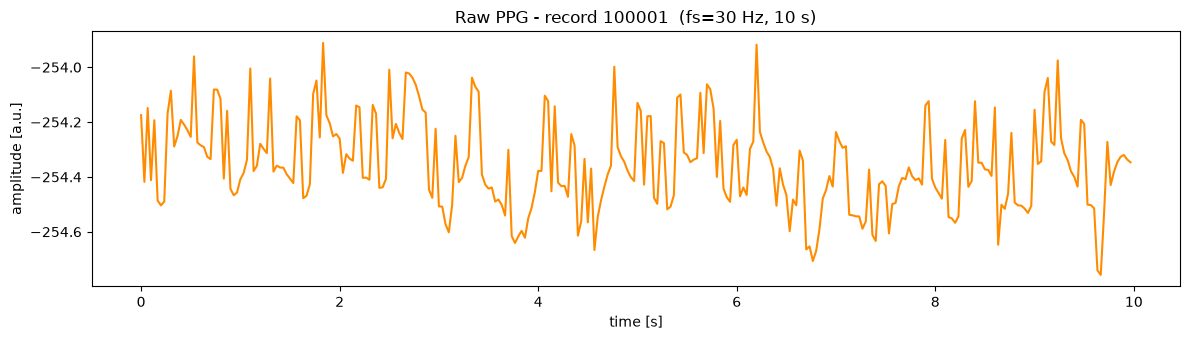

In [7]:
rid = records[0]
sig, fs = read_ppg(PPG_ZIP, rid)
t = np.arange(len(sig)) / fs

plt.figure(figsize=(12, 3.5))
plt.plot(t, sig, color='darkorange')
plt.title(f'Raw PPG - record {rid}  (fs={fs} Hz, {len(sig)/fs:.0f} s)')
plt.xlabel('time [s]')
plt.ylabel('amplitude [a.u.]')
plt.tight_layout()
plt.show()

# **Band-pass filtered PPG**
A 0.5-8 Hz band-pass (the filtering step mentioned in the proposal's PPG pipeline) removes the baseline and reveals the pulsatile waveform whose **morphology** changes with age.

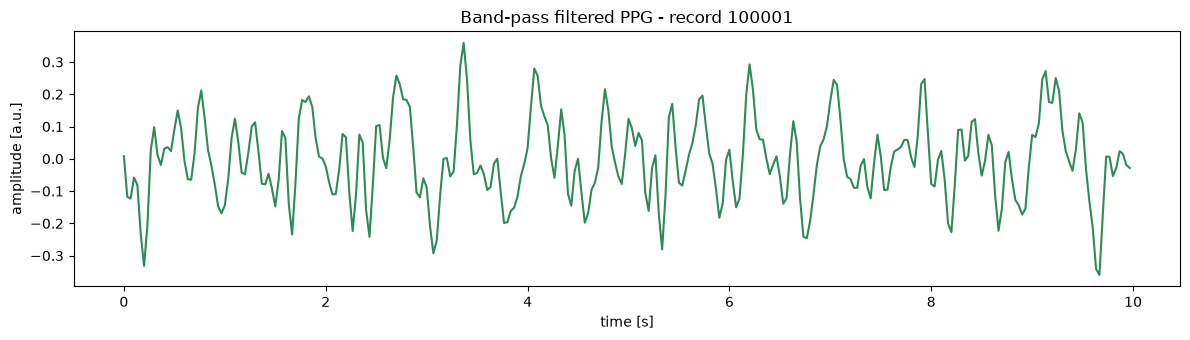

In [8]:
def bandpass(x, fs, low=0.5, high=8.0, order=4):
    high = min(high, fs / 2 - 0.1)
    b, a = butter(order, [low, high], btype='band', fs=fs)
    return filtfilt(b, a, x)


clean = bandpass(sig, fs)

plt.figure(figsize=(12, 3.5))
plt.plot(t, clean, color='seagreen')
plt.title(f'Band-pass filtered PPG - record {rid}')
plt.xlabel('time [s]')
plt.ylabel('amplitude [a.u.]')
plt.tight_layout()
plt.show()

# **PPG of subjects at different ages**
A first qualitative look at whether the pulse morphology differs between a younger and an older subject.

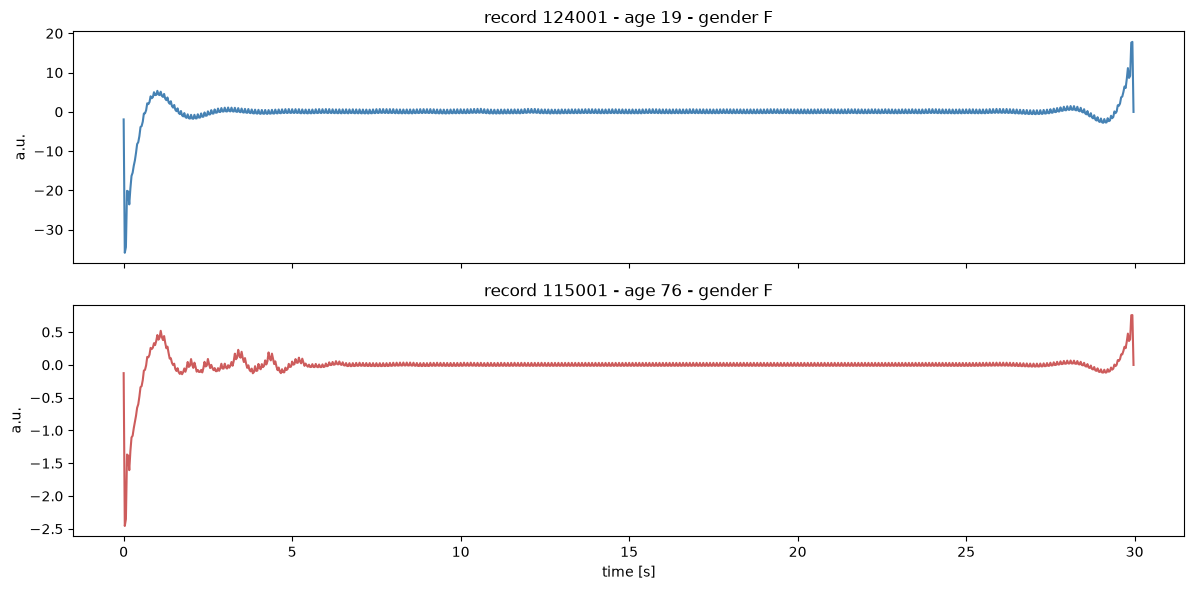

In [9]:
info['ID'] = info['ID'].astype(str)
info['_age'] = pd.to_numeric(info['Age [years]'], errors='coerce')
valid = info.dropna(subset=['_age'])
valid = valid[valid['ID'].isin(records)]

young = valid.loc[valid['_age'].idxmin()]
old = valid.loc[valid['_age'].idxmax()]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, row, color in zip(axes, [young, old], ['steelblue', 'indianred']):
    s, f = read_ppg(PPG_ZIP, row['ID'])
    ax.plot(np.arange(len(s)) / f, bandpass(s, f), color=color)
    ax.set_title(f"record {row['ID']} - age {int(row['_age'])} - gender {row['Gender']}")
    ax.set_ylabel('a.u.')
axes[-1].set_xlabel('time [s]')
plt.tight_layout()
plt.show()